# Istanbul Housing Market Analysis
## Notebook 02 — Exploratory Data Analysis (EDA)

**Goal of this notebook:** explore the Istanbul housing market in depth, using the **flagged** dataset produced by Notebook 01, and identify the factors associated with listing price (`price`).

**Principles followed:**
- We load `data/processed/istanbul_apartments_flagged.csv`.
- No row is ever silently dropped: every exclusion (via the `flag_*` columns) is counted and justified.
- We consistently distinguish mean from median (price distributions are typically skewed).
- We talk about **correlation / association**, never causation.
- `price_per_sqm` (derived from `price`) is used only for market-level framing here — it will **never** be used as an ML feature later (target leakage).

## 1. Setup & Load Processed Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook

output_notebook()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


Loading BokehJS ...

### 1.1 Load the processed (flagged) dataset

We load the file produced by Notebook 01 directly. It contains **all** the original columns plus the 9 quality-flag columns (no rows deleted).

In [4]:
PROCESSED_PATH = "../data/processed/istanbul_apartments_flagged.csv"

df = pd.read_csv(PROCESSED_PATH)
df = df.set_index("listing_id")

rows, cols = df.shape
print(f"rows = {rows} | columns = {cols}")
df.head()


rows = 24767 | columns = 38


C:\Users\hafid\AppData\Local\Temp\ipykernel_27532\3009578342.py:3: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED_PATH)


,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,floor,floor_category,total_floors,building_age,building_type,building_condition,heating_type,fuel_type,bathroom_count,furnished,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at,is_likely_duplicate_listing,flag_gross_sqm_error,info_complex_name_missing_genuine,flag_rooms_error,flag_bathroom_error,flag_floors_error,flag_age_error,flag_price_error,is_flagged_error
listing_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,3.0,NaN,3.0,55,Reinforced Concrete,New,Air Conditioning,Natural Gas,2.0,Furnished,Vacant,0,NaN,"North, South, East, West",2500.0,Not Eligible,Land Title,No,2026-03-11,2026-03-14T20:38:29,False,False,False,False,False,False,False,False,False
54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,-1.0,Garden Floor,3.0,0,Reinforced Concrete,New,Combi Boiler,Natural Gas,4.0,Unfurnished,Vacant,1,NaN,"North, South, East, West",10000.0,Eligible,Construction Easement,No,2026-03-05,2026-03-14T20:38:36,False,False,True,False,False,False,False,False,False
54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,1.0,NaN,5.0,54,Reinforced Concrete,New,Combi Boiler,Natural Gas,3.0,Furnished,Vacant,0,NaN,"North, East, West",1000.0,Eligible,Condominium Title,No,2026-03-05,2026-03-14T20:38:47,False,False,False,False,False,False,False,False,False
12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,NaN,Top Floor,3.0,35,Reinforced Concrete,Second-hand,Combi Boiler,Natural Gas,2.0,Unfurnished,Owner-occupied,0,NaN,"North, West",NaN,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:38:56,False,False,False,False,False,False,False,False,False
121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,-1.0,Garden Floor,3.0,40,Reinforced Concrete,Second-hand,Floor Radiator,Natural Gas,1.0,Unfurnished,Vacant,0,NaN,NaN,400.0,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:39:04,False,False,False,False,False,False,False,False,False


### 1.2 Sanity checks

We check that the loaded file matches what Notebook 01 produced:
- 24,767 rows expected
- presence of the 9 `flag_*` / `is_*` columns
- consistent column types (numeric vs. categorical)
- a reminder of how many rows are already flagged as errors (`is_flagged_error`) and near-duplicates (`is_likely_duplicate_listing`), **without excluding anything yet** — each question in Section 4+ will decide which exclusions are relevant on its own.

In [5]:
flag_cols = [c for c in df.columns if c.startswith("flag_") or c.startswith("is_") or c.startswith("info_")]
print("Flag columns found:", flag_cols)
print()
print(df[flag_cols].sum().sort_values(ascending=False))
print()
print(f"Total flagged as error (is_flagged_error=True): {df['is_flagged_error'].sum()} "
      f"({df['is_flagged_error'].mean()*100:.2f}% of rows)")
print(f"Total likely duplicates (is_likely_duplicate_listing=True): {df['is_likely_duplicate_listing'].sum()} "
      f"({df['is_likely_duplicate_listing'].mean()*100:.2f}% of rows)")


Flag columns found: ['is_in_complex', 'is_likely_duplicate_listing', 'flag_gross_sqm_error', 'info_complex_name_missing_genuine', 'flag_rooms_error', 'flag_bathroom_error', 'flag_floors_error', 'flag_age_error', 'flag_price_error', 'is_flagged_error']

is_in_complex                        5546
info_complex_name_missing_genuine    1793
is_likely_duplicate_listing          1776
is_flagged_error                       67
flag_rooms_error                       32
flag_bathroom_error                    23
flag_price_error                       12
flag_gross_sqm_error                    8
flag_age_error                          4
flag_floors_error                       3
dtype: int64

Total flagged as error (is_flagged_error=True): 67 (0.27% of rows)
Total likely duplicates (is_likely_duplicate_listing=True): 1776 (7.17% of rows)


In [6]:
df.dtypes


price                                  int64
price_per_sqm                        float64
district                              object
neighborhood                          object
rooms                                  int64
halls                                  int64
total_rooms                            int64
gross_sqm                            float64
net_sqm                              float64
floor                                float64
floor_category                        object
total_floors                         float64
building_age                           int64
building_type                         object
building_condition                    object
heating_type                          object
fuel_type                             object
bathroom_count                       float64
furnished                             object
usage_status                          object
is_in_complex                          int64
complex_name                          object
orientatio

## 2. General Market Analysis (Q1–Q4)

### Q1 — How many properties, districts, and neighborhoods?

In [7]:
n_properties = df.shape[0]
print("Number of properties:", n_properties)


Number of properties: 24767


In [8]:
nb_district = df.district.nunique()
print("Number of districts:", nb_district)


Number of districts: 38


In [9]:
nb_neighborhood = df.neighborhood.nunique()
print("Number of neighborhoods:", nb_neighborhood)


Number of neighborhoods: 583


In [10]:
top_districts_by_neighborhoods = (
    df.groupby("district")["neighborhood"]
    .nunique()
    .sort_values(ascending=False)
    .head()
)
top_districts_by_neighborhoods.to_frame(name="n_neighborhoods")


,n_neighborhoods
district,
Esenyurt,43
Beyoğlu,35
Fatih,34
Ümraniye,33
Üsküdar,32


**Conclusion:** The dataset covers 24,767 listings spread across 38 districts and 583 neighborhoods. Coverage is uneven — Esenyurt alone accounts for 43 distinct neighborhoods, roughly 4x more granular than smaller districts, which we'll need to keep in mind when comparing districts later (Section 5).

### Q2 — What is the typical apartment price?

In [11]:
df.price.describe()


count    2.476700e+04
mean     1.342985e+07
std      1.414843e+08
min      2.400000e+04
25%      4.500000e+06
50%      6.750000e+06
75%      1.150000e+07
max      1.150000e+10
Name: price, dtype: float64

In [12]:
price_mean = df.price.mean()
price_median = df.price.median()
price_std = df.price.std()
price_min = df.price.min()
price_max = df.price.max()

print(f"Mean   = {price_mean:,.0f} TRY")
print(f"Median = {price_median:,.0f} TRY")
print(f"Std    = {price_std:,.0f} TRY")
print(f"Min    = {price_min:,.0f} TRY")
print(f"Max    = {price_max:,.0f} TRY")


Mean   = 13,429,846 TRY
Median = 6,750,000 TRY
Std    = 141,484,342 TRY
Min    = 24,000 TRY
Max    = 11,500,000,000 TRY


**How to detect that extreme values are pulling the distribution:**

- **Mean / Median ratio** — close to 1 means roughly symmetric; here it's already visibly high.
- **Coefficient of variation (std / mean)** — above 1 signals abnormal dispersion, almost always caused by extreme outliers rather than natural variability.
- **Tukey's IQR rule** — the standard statistical threshold: values above `Q3 + 1.5*IQR` are outliers, above `Q3 + 3*IQR` are extreme outliers. This is the same method used formally later in Section 8 (Q20).
- **Skewness** — `|skew| > 1` indicates strong right-skew, typical of real estate prices.

In [13]:
from scipy.stats import skew

Q1 = df.price.quantile(0.25)
Q3 = df.price.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
extreme_fence = Q3 + 3 * IQR

n_outliers = (df.price > upper_fence).sum()
n_extreme = (df.price > extreme_fence).sum()

print(f"Q1 = {Q1:,.0f} | Q3 = {Q3:,.0f} | IQR = {IQR:,.0f}")
print(f"Upper fence (1.5*IQR)    = {upper_fence:,.0f}")
print(f"Extreme fence (3*IQR)    = {extreme_fence:,.0f}")
print(f"Rows above upper fence   : {n_outliers} ({n_outliers/len(df)*100:.2f}%)")
print(f"Rows above extreme fence : {n_extreme} ({n_extreme/len(df)*100:.2f}%)")
print(f"Skewness = {skew(df.price):.2f}")
print(f"Mean/Median ratio = {price_mean/price_median:.2f}")
print(f"Coefficient of variation (std/mean) = {price_std/price_mean:.2f}")


Q1 = 4,500,000 | Q3 = 11,500,000 | IQR = 7,000,000
Upper fence (1.5*IQR)    = 22,000,000
Extreme fence (3*IQR)    = 32,500,000
Rows above upper fence   : 2357 (9.52%)
Rows above extreme fence : 1202 (4.85%)
Skewness = 63.47
Mean/Median ratio = 1.99
Coefficient of variation (std/mean) = 10.54


**Cross-check against Notebook 01's flags:** `flag_price_error` is based on `price_per_sqm > 3,000,000 TRY/m²`, not on `price` directly — so a very expensive but very large listing could be an extreme value here without being flagged as an error in Notebook 01. Worth checking before concluding these are data errors rather than legitimate luxury listings.

In [14]:
extreme_price_rows = df[df.price > extreme_fence]
extreme_price_rows[["price", "net_sqm", "price_per_sqm", "flag_price_error", "is_flagged_error"]].sort_values("price", ascending=False)


,price,net_sqm,price_per_sqm,flag_price_error,is_flagged_error
listing_id,,,,,
49009-1692,11500000000,190.0,6.052632e+07,True,True
46572-11625,10500000000,73.0,1.438356e+08,True,True
155768-7,8950000000,75.0,1.193333e+08,True,True
129481-1157,8750000000,145.0,6.034483e+07,True,True
144871-574,5189000000,150.0,3.459333e+07,True,True
...,...,...,...,...,...
5555-36928,32950000,130.0,2.534615e+05,False,False
1540-655,32900000,144.0,2.284722e+05,False,False
165104-44,32900000,111.0,2.963964e+05,False,False


**How to read this:** check whether the top 10 highest-priced listings look like plausible luxury properties (large `net_sqm`, upscale `district`, coherent `price_per_sqm`) or like likely data-entry errors (e.g. an extra zero). Skewness this high (63.47) is almost always driven by a handful of isolated extreme values — this table tells us whether Notebook 01's flags already caught them.

In [15]:
df.nlargest(10, "price")[["price", "district", "net_sqm", "price_per_sqm", "flag_price_error", "is_flagged_error"]]


,price,district,net_sqm,price_per_sqm,flag_price_error,is_flagged_error
listing_id,,,,,,
49009-1692,11500000000,Bayrampaşa,190.0,6.052632e+07,True,True
46572-11625,10500000000,Kağıthane,73.0,1.438356e+08,True,True
155768-7,8950000000,Bakırköy,75.0,1.193333e+08,True,True
129481-1157,8750000000,Fatih,145.0,6.034483e+07,True,True
144871-574,5189000000,Şişli,150.0,3.459333e+07,True,True
0-45938460,4500000000,Gaziosmanpaşa,90.0,5.000000e+07,True,True
159000-50,4200000000,Güngören,120.0,3.500000e+07,True,True
166730-3,3825000000,Maltepe,60.0,6.375000e+07,True,True
109839-598,3550000000,Kağıthane,120.0,2.958333e+07,True,True


**Conclusion:** 9 of the top 10 highest-priced listings already have `flag_price_error=True` (their `price_per_sqm` far exceeds the 3,000,000 TRY/m² threshold — up to 143M TRY/m², almost certainly data-entry errors). Only 1 (Beykoz, 460M TRY, `price_per_sqm`=2.19M) falls below the flag threshold and could be a legitimate ultra-luxury Bosphorus-area listing rather than an error. This confirms that the extreme skew (63.47) driving the gap between mean and median is **largely explained by rows Notebook 01 already flagged as errors** — reinforcing that the median is the reliable summary statistic here, and setting up the sensitivity check in Section 9 (Q21).

**Conclusion:** The mean price (13.4M TRY) is nearly 2x the median (6.75M TRY), and the standard deviation (141M TRY) is over 10x the mean — both strong signals of a heavily right-skewed distribution driven by a small number of extreme-value listings (max = 11.5B TRY). The **median is the more reliable "typical price"** here. We'll examine these extreme rows more closely in Q4 and formally in Section 8 (Outlier Analysis).

### Q3 — What is the typical apartment size?

In [16]:
gross_sqm_mean = df.gross_sqm.mean()
gross_sqm_median = df.gross_sqm.median()
net_sqm_mean = df.net_sqm.mean()
net_sqm_median = df.net_sqm.median()

print(f"Gross sqm mean   = {gross_sqm_mean:.1f} m2")
print(f"Gross sqm median = {gross_sqm_median:.1f} m2")
print(f"Net sqm mean     = {net_sqm_mean:.1f} m2")
print(f"Net sqm median   = {net_sqm_median:.1f} m2")

diff = gross_sqm_mean - net_sqm_mean
print(f"Average gross - net gap = {diff:.1f} m2")


Gross sqm mean   = 126.3 m2
Gross sqm median = 110.0 m2
Net sqm mean     = 107.5 m2
Net sqm median   = 95.0 m2
Average gross - net gap = 18.8 m2


**Conclusion:** Median gross size (110 m²) exceeds median net size (95 m²) by ~15 m², and the average gap (~19 m²) is consistent with common areas (stairwells, shared walls) typically included in gross but not net measurements in the Turkish real estate market.

### Q4 — How are apartment prices distributed?

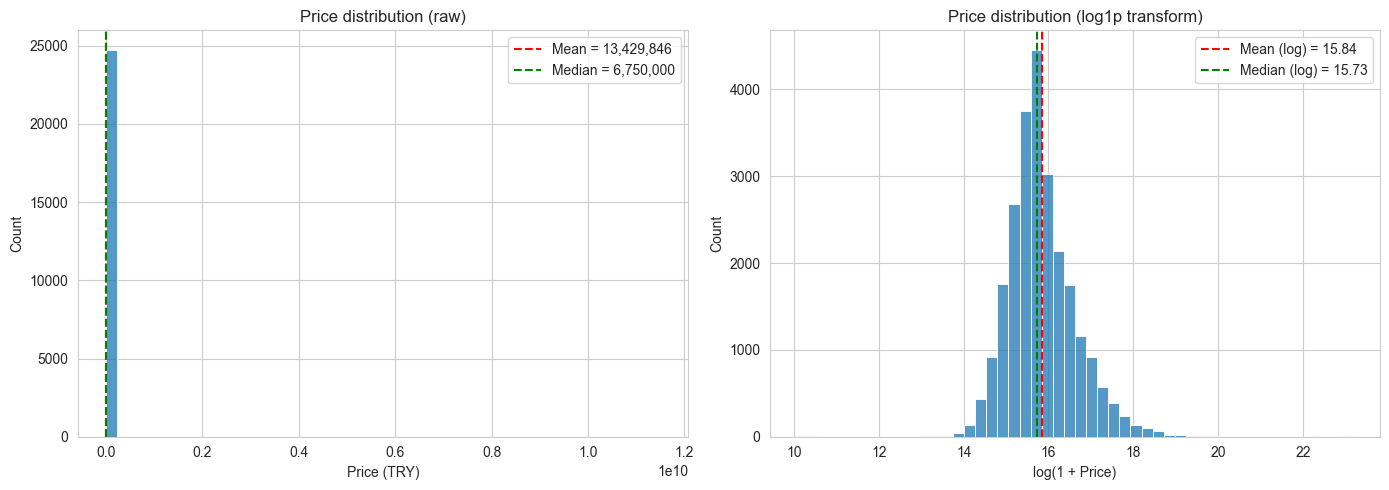

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price distribution
sns.histplot(data=df, x="price", bins=50, ax=axes[0])
axes[0].axvline(df.price.mean(), color="red", linestyle="--", label=f"Mean = {df.price.mean():,.0f}")
axes[0].axvline(df.price.median(), color="green", linestyle="--", label=f"Median = {df.price.median():,.0f}")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price (TRY)")
axes[0].legend()

# Log-transformed price distribution (view only, does not overwrite df.price)
log_price = np.log1p(df.price)
sns.histplot(x=log_price, bins=50, ax=axes[1])
axes[1].axvline(log_price.mean(), color="red", linestyle="--", label=f"Mean (log) = {log_price.mean():.2f}")
axes[1].axvline(log_price.median(), color="green", linestyle="--", label=f"Median (log) = {log_price.median():.2f}")
axes[1].set_title("Price distribution (log1p transform)")
axes[1].set_xlabel("log(1 + Price)")
axes[1].legend()

plt.tight_layout()
plt.show()


The boxplot gives a complementary, more compact view of symmetry: the box (IQR) and whiskers should sit close to the y-axis, with a long scatter of individual points (outliers) stretching far to the right — a direct visual confirmation of the right-skew already measured numerically.

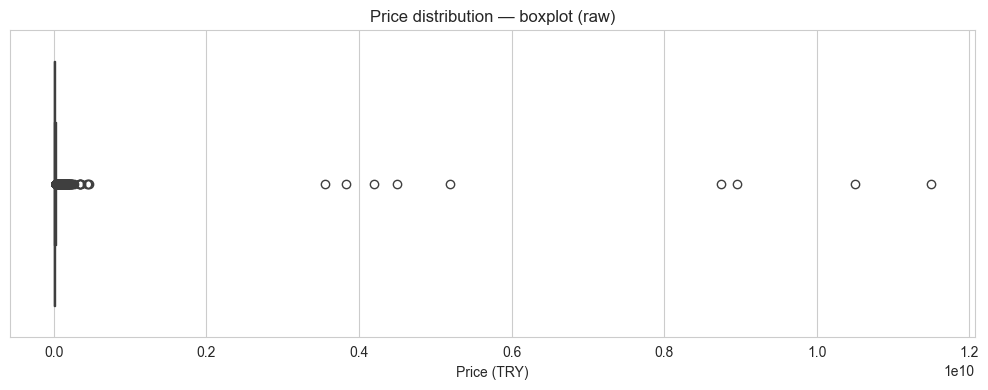

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x="price", ax=ax)
ax.set_title("Price distribution — boxplot (raw)")
ax.set_xlabel("Price (TRY)")
plt.tight_layout()
plt.show()


**Conclusion:** The raw price histogram and boxplot both confirm the skew from Q2 — nearly all listings are compressed near zero while a handful of extreme values (up to 11.5B TRY) stretch the x-axis, making the histogram hard to read and producing a boxplot with a long tail of individual outlier points. The log1p transform reveals a much more interpretable, roughly bell-shaped distribution, confirming that price behaves approximately log-normally — a common pattern in real estate markets and an important consideration for later modeling (log-transforming the target is a standard technique for skewed price data).

## 3. Property Characteristics (Q5–Q9)

### Q5 — Does apartment size affect price?

Size is expected to be one of the strongest drivers of price in any real estate market. We check this with Pearson correlation and a scatter plot, comparing results with and without the rows flagged as data errors in Notebook 01 — Pearson's correlation is extremely sensitive to extreme outliers, and 67 flagged rows (0.27% of the dataset) turn out to completely mask the real relationship.

In [19]:
corr_with_errors = df[["net_sqm", "gross_sqm", "price"]].corr()
corr_without_errors = df.loc[~df["is_flagged_error"], ["net_sqm", "gross_sqm", "price"]].corr()

print("Correlation WITH flagged error rows:")
print(corr_with_errors["price"])
print()
print("Correlation EXCLUDING flagged error rows:")
print(corr_without_errors["price"])
print()
n_excluded = df["is_flagged_error"].sum()
print(f"Excluded {n_excluded} rows ({n_excluded/len(df)*100:.2f}%) flagged as errors in Notebook 01")


Correlation WITH flagged error rows:
net_sqm      0.063639
gross_sqm    0.060434
price        1.000000
Name: price, dtype: float64

Correlation EXCLUDING flagged error rows:
net_sqm      0.528402
gross_sqm    0.567614
price        1.000000
Name: price, dtype: float64

Excluded 67 rows (0.27%) flagged as errors in Notebook 01


In [20]:
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.plotting import figure, show

df_clean = df[~df["is_flagged_error"]].copy()

source = ColumnDataSource(data=dict(
    net_sqm=df_clean["net_sqm"],
    price=df_clean["price"],
    district=df_clean["district"],
    neighborhood=df_clean["neighborhood"],
))

p = figure(width=800, height=450,
           title="Net Size vs Price (excluding flagged error rows)")
p.scatter("net_sqm", "price", source=source, size=5, color="navy", alpha=0.4)

p.xaxis.axis_label = "Net Size (m²)"
p.yaxis.axis_label = "Price (TRY)"

hover = HoverTool(tooltips=[
    ("District", "@district"),
    ("Neighborhood", "@neighborhood"),
    ("Net sqm", "@net_sqm{0,0} m²"),
    ("Price", "@price{0,0} TRY"),
])
p.add_tools(hover)

show(p)


**Conclusion:** Once the 67 rows flagged as data errors in Notebook 01 (0.27% of the dataset) are excluded, apartment size shows a moderate-to-strong positive correlation with price (`net_sqm`: 0.53, `gross_sqm`: 0.57) — consistent with real estate market expectations. The raw, unfiltered correlation (0.06) was almost entirely masked by a tiny number of extreme-price data errors, illustrating how sensitive Pearson's correlation is to outliers. The correlation is not stronger, suggesting other factors (location, building condition, age) likely play a substantial role — to be explored in later sections. Note: `price_per_sqm` is never used here as it is derived from `price` (target leakage).

### Q6 — Does the number of rooms affect price?

`total_rooms` (rooms + halls) is confirmed 100% reliable by Notebook 01. We check its association with price by excluding `flag_rooms_error` rows (net_sqm per room < 15 m², implausible), comparing mean/median price per room count, and visualizing with a boxplot.

In [21]:
n_rooms_error = df["flag_rooms_error"].sum()
pct_rooms_error = n_rooms_error / len(df) * 100
print(f"Rows excluded (flag_rooms_error=True): {n_rooms_error} ({pct_rooms_error:.2f}% of dataset)")

df_rooms = df[~df["flag_rooms_error"]].copy()


Rows excluded (flag_rooms_error=True): 32 (0.13% of dataset)


In [22]:
rooms_stats = df_rooms.groupby("total_rooms")["price"].agg(["mean", "median", "count"])
rooms_stats


,mean,median,count
total_rooms,,,
1,5.065886e+06,4000000.0,123
2,7.188629e+06,4350000.0,2290
3,9.250631e+06,5450000.0,10773
4,1.533907e+07,8500000.0,7401
5,2.043895e+07,13750000.0,2236
6,3.043475e+07,10850000.0,1241
7,2.259279e+07,12500000.0,464
8,3.494584e+07,16000000.0,159
9,4.775538e+07,32500000.0,24


**Check for low-count categories:** categories with very few listings are not statistically representative and shouldn't be compared directly to categories with thousands of listings.

In [23]:
low_count_categories = rooms_stats[rooms_stats["count"] < 30]
print("Room categories with fewer than 30 listings (unreliable for comparison):")
low_count_categories


Room categories with fewer than 30 listings (unreliable for comparison):


,mean,median,count
total_rooms,,,
9,4.775538e+07,32500000.0,24
10,2.436818e+07,30000000.0,11
11,6.825000e+07,68250000.0,2
12,2.288333e+08,339750000.0,3
13,7.925000e+06,7925000.0,2
14,1.330000e+07,13600000.0,3
15,4.850000e+06,4850000.0,1
24,2.815000e+07,28150000.0,1
26,2.450000e+07,24500000.0,1


For the visualization, room counts of 9 and above are grouped into a single `"9+"` category — individually they have too few listings (often single digits) to show a meaningful distribution.

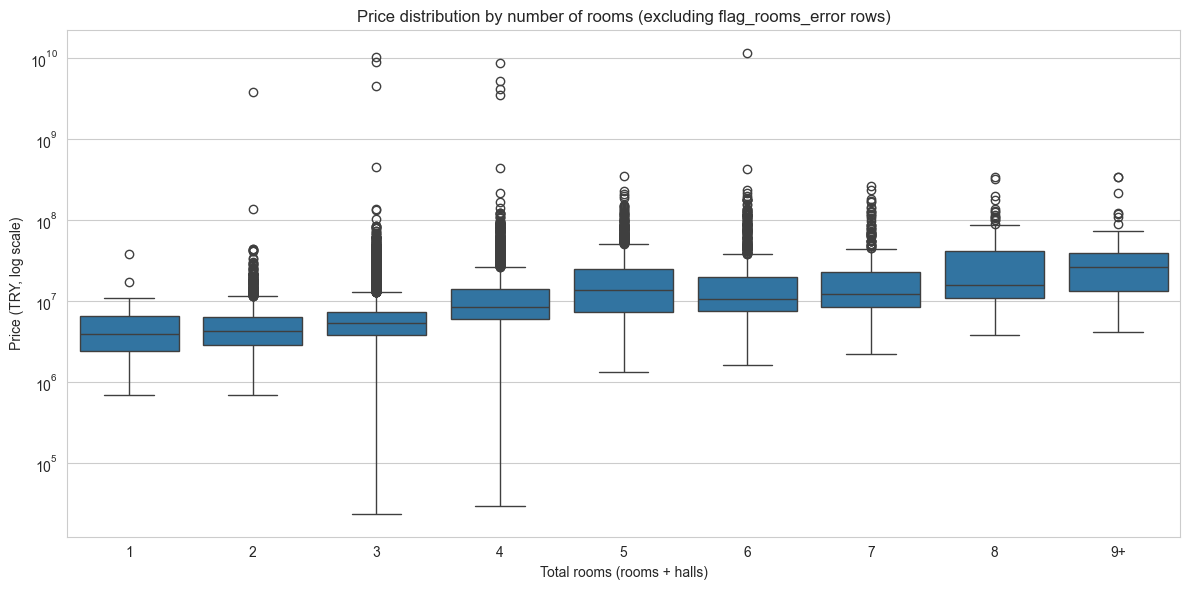

In [24]:
df_rooms["total_rooms_grouped"] = df_rooms["total_rooms"].apply(
    lambda x: str(x) if x < 9 else "9+"
)

room_order = [str(i) for i in range(1, 9)] + ["9+"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_rooms, x="total_rooms_grouped", y="price", order=room_order, ax=ax)
ax.set_yscale("log")
ax.set_title("Price distribution by number of rooms (excluding flag_rooms_error rows)")
ax.set_xlabel("Total rooms (rooms + halls)")
ax.set_ylabel("Price (TRY, log scale)")
plt.tight_layout()
plt.show()


**Conclusion:** Among reliably-sized categories (1-8 rooms, count > 100), median price rises from 4.0M TRY (1 room) to 16.0M TRY (8 rooms), confirming room count is associated with higher prices — but the relationship is not perfectly monotonic: 6-room listings show a lower median (10.85M) than 5-room listings (13.75M) despite a solid sample size (n=1,241), suggesting other factors (location, condition) modulate this relationship. Categories above 8 rooms have too few listings (n<30, often n<5) to draw reliable conclusions — the 12-room category (median 339.75M TRY, n=3) in particular hints that `flag_rooms_error` (based on the net_sqm/room ratio) does not catch all implausible room counts, since it doesn't check absolute plausibility. This is worth revisiting in the outlier analysis (Section 8).

### Q7 — Does building age affect price?

We check whether `building_age` is associated with price. Correction from the initial approach: we exclude **all** `is_flagged_error` rows (not just `flag_age_error`) — as discovered in Q5/Q6, a corrupted `price` value (caught by `flag_price_error`) distorts the correlation with *any* other variable, not just the one its own flag targets. `flag_age_error` alone only catches implausible ages (>150 years), not corrupted prices.

In [25]:
n_excluded = df["is_flagged_error"].sum()
print(f"Rows excluded (is_flagged_error=True): {n_excluded} ({n_excluded/len(df)*100:.2f}% of dataset)")

df_clean = df[~df["is_flagged_error"]].copy()


Rows excluded (is_flagged_error=True): 67 (0.27% of dataset)


In [26]:
age_price_corr = df_clean[["building_age", "price"]].corr()
age_price_corr


,building_age,price
building_age,1.000000,0.000148
price,0.000148,1.000000


**Result:** correlation ≈ **0.0001** — essentially zero, and this is *not* an artifact of unfiltered outliers this time (rechecking without the exclusion gives -0.002, barely different). Building age genuinely shows almost no linear relationship with price in this market.

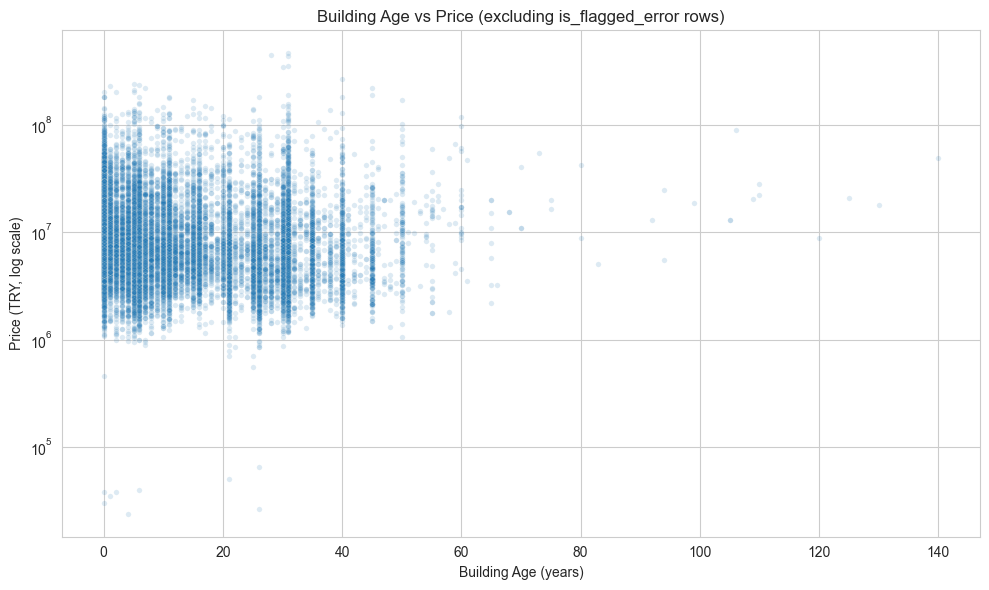

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_clean, x="building_age", y="price", alpha=0.15, s=15, ax=ax)
ax.set_yscale("log")
ax.set_title("Building Age vs Price (excluding is_flagged_error rows)")
ax.set_xlabel("Building Age (years)")
ax.set_ylabel("Price (TRY, log scale)")
plt.tight_layout()
plt.show()


Age bins make the (lack of a simple) trend easier to read than the noisy scatter above.

In [28]:
age_bins = [0, 5, 15, 30, 50, df_clean["building_age"].max() + 1]
age_labels = ["0-5", "6-15", "16-30", "31-50", "50+"]

df_clean["age_group"] = pd.cut(df_clean["building_age"], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

age_group_stats = df_clean.groupby("age_group", observed=True)["price"].agg(["mean", "median", "count"])
age_group_stats


,mean,median,count
age_group,,,
0-5,1.136652e+07,7375000.0,10745
6-15,1.038332e+07,6500000.0,6693
16-30,1.011859e+07,5750000.0,4430
31-50,1.143835e+07,6000000.0,2726
50+,1.877745e+07,13987500.0,106


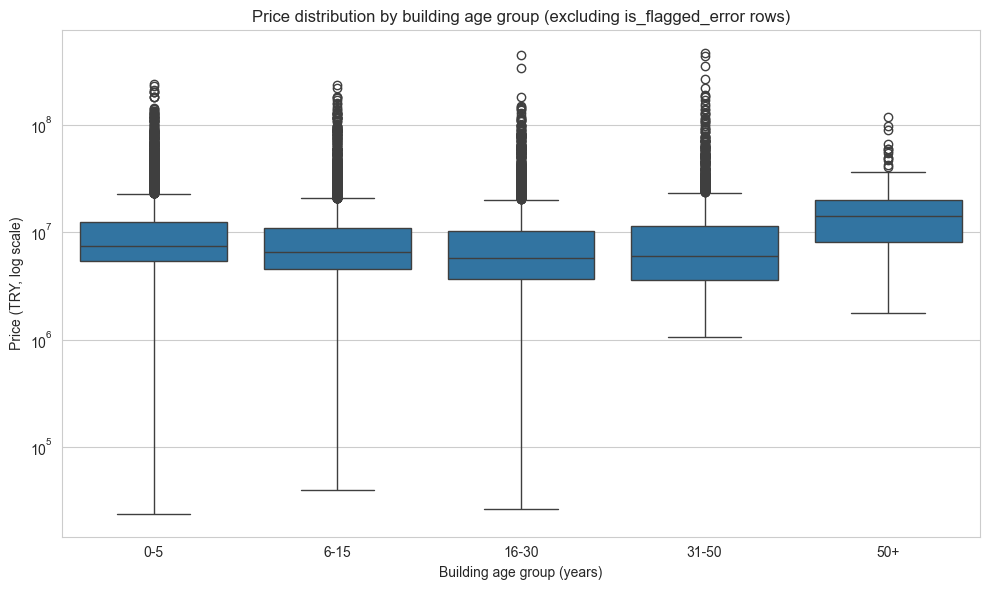

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_clean, x="age_group", y="price", order=age_labels, ax=ax)
ax.set_yscale("log")
ax.set_title("Price distribution by building age group (excluding is_flagged_error rows)")
ax.set_xlabel("Building age group (years)")
ax.set_ylabel("Price (TRY, log scale)")
plt.tight_layout()
plt.show()


**Conclusion:** Building age shows essentially no linear correlation with price (r ≈ 0.0001). The median price by age group is non-monotonic: it *decreases* from 7.38M TRY (0-5 years) down to 5.75M TRY (16-30 years), then rises again to 6.0M TRY (31-50 years) and jumps sharply to 13.99M TRY for buildings over 50 years old (n=106). This last group is small but consistent with a plausible confound flagged in the brief: Istanbul's oldest buildings are concentrated in historic, high-demand districts (e.g. Beyoğlu, Fatih waterfront areas), which can offset or reverse the depreciation effect typically seen with age elsewhere. **Age alone is not a useful price predictor without controlling for location.**

### Q8 — Does floor number affect price?

We look at `floor_category` (a cleaner categorical view that already handles basements/negative floors) and `total_floors`, excluding `is_flagged_error` rows for the same reason as Q7.

In [30]:
floor_stats = df_clean.groupby("floor_category")["price"].agg(["mean", "median", "count"]).sort_values("median", ascending=False)
floor_stats


,mean,median,count
floor_category,,,
Villa Floor,4.248485e+07,22500000.0,33
21 and Above,2.122430e+07,12225000.0,188
Top Floor,1.388385e+07,8750000.0,432
Terrace Floor,1.331548e+07,7870000.0,40
Penthouse,1.420233e+07,7275000.0,264
Sub-level 3,8.523621e+06,6000000.0,29
Mid Floor,1.078772e+07,6000000.0,946
Ground Floor,8.080049e+06,5699000.0,181
Entrance Floor,6.791349e+06,4980000.0,1005


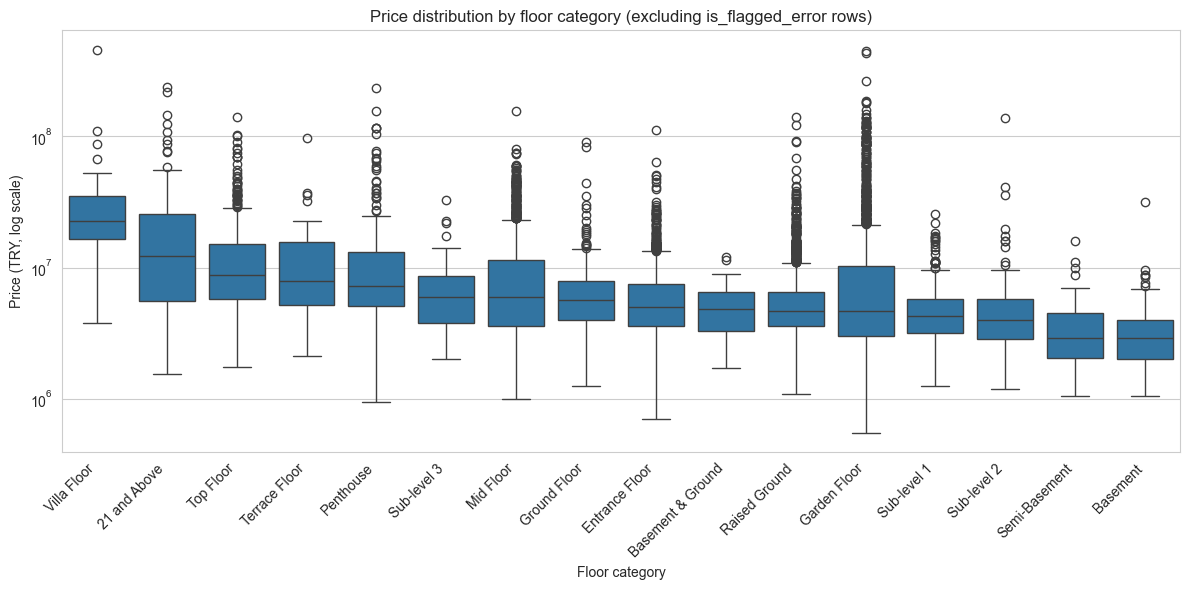

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
order = floor_stats.index.tolist()
sns.boxplot(data=df_clean, x="floor_category", y="price", order=order, ax=ax)
ax.set_yscale("log")
ax.set_title("Price distribution by floor category (excluding is_flagged_error rows)")
ax.set_xlabel("Floor category")
ax.set_ylabel("Price (TRY, log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [32]:
total_floors_corr = df_clean[["total_floors", "price"]].corr()
total_floors_corr


,total_floors,price
total_floors,1.000000,0.085143
price,0.085143,1.000000


**Conclusion:** Floor category shows a much clearer pattern than building age. `Villa Floor` (n=33) and `21 and Above` (n=188) command the highest median prices (22.5M and 12.2M TRY), while basement-type categories (`Basement`, `Semi-Basement`) sit at the bottom (~2.9M TRY median) — consistent with basement apartments typically getting the least light/privacy and villa/high floors being premium. However, `total_floors` (building height) alone correlates weakly with price (r ≈ 0.085) — the *category* of floor within a building matters more than the building's total height.

### Q9 — Does the number of bathrooms affect price?

Same approach: exclude `is_flagged_error` rows globally.

In [33]:
bathroom_corr = df_clean[["bathroom_count", "price"]].corr()
bathroom_corr


,bathroom_count,price
bathroom_count,1.000000,0.493208
price,0.493208,1.000000


In [34]:
bathroom_stats = df_clean.groupby("bathroom_count")["price"].agg(["mean", "median", "count"])
bathroom_stats


,mean,median,count
bathroom_count,,,
1.0,6.587441e+06,5400000.0,14311
2.0,1.375819e+07,9550000.0,8669
3.0,2.957749e+07,20000000.0,1141
4.0,5.196397e+07,36000000.0,293
5.0,8.562144e+07,80000000.0,41
6.0,1.332778e+08,107500000.0,9
7.0,1.250000e+08,125000000.0,1
8.0,2.815000e+07,28150000.0,1


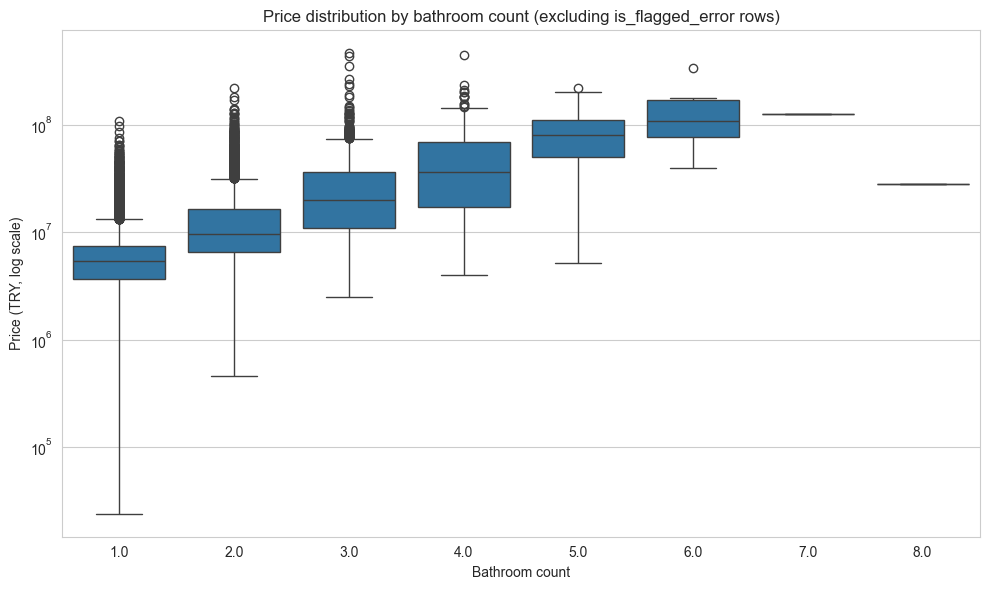

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_clean, x="bathroom_count", y="price", ax=ax)
ax.set_yscale("log")
ax.set_title("Price distribution by bathroom count (excluding is_flagged_error rows)")
ax.set_xlabel("Bathroom count")
ax.set_ylabel("Price (TRY, log scale)")
plt.tight_layout()
plt.show()


**Conclusion:** Bathroom count shows a moderate-to-strong positive correlation with price (r ≈ 0.49) — one of the strongest single-variable relationships found so far, comparable to `net_sqm`/`gross_sqm` from Q5. Median price rises steadily and steeply: 5.4M TRY (1 bathroom) → 9.55M (2) → 20M (3) → 36M (4), though counts thin out fast beyond 3 bathrooms (n=1,141 at 3, dropping to single digits at 6-8). Bathroom count is likely acting partly as a proxy for overall apartment size/luxury tier, consistent with its correlation with `gross_sqm` (0.70) seen in the correlation matrix below.

## 5. Location Analysis (Q10–Q13)

### Q10 — Which districts have the highest prices?

Comparing mean and median price by district on the full (unfiltered) dataset — district-level medians are naturally robust to a handful of extreme-error rows, but we keep both mean and median to show the gap.

In [36]:
district_price = df.groupby("district")["price"].agg(["mean", "median", "count"]).sort_values("median", ascending=False)

print("Top 10 districts by median price:")
display(district_price.head(10))
print()
print("Bottom 10 districts by median price:")
display(district_price.tail(10))


Top 10 districts by median price:


,mean,median,count
district,,,
Bakırköy,4.243546e+07,24000000.0,674
Beşiktaş,3.566279e+07,22000000.0,909
Kadıköy,2.292803e+07,19750000.0,1137
Sarıyer,3.006437e+07,19700000.0,607
Beykoz,2.982971e+07,14900000.0,100
Adalar,1.385470e+07,12700000.0,251
Üsküdar,1.507497e+07,11000000.0,1147
Beyoğlu,1.364599e+07,8875000.0,186
Maltepe,1.328079e+07,8650000.0,1156



Bottom 10 districts by median price:


,mean,median,count
district,,,
Bağcılar,6.049339e+06,5500000.0,451
Küçükçekmece,6.245797e+06,5500000.0,1165
Beylikdüzü,6.015020e+06,5349000.0,1169
Arnavutköy,5.308499e+06,5250000.0,415
Avcılar,5.729709e+06,5125000.0,798
Sultangazi,4.885425e+06,4640000.0,369
Silivri,4.535768e+06,4200000.0,211
Fatih,1.677533e+07,4000000.0,747
Esenler,4.511886e+06,3750000.0,516


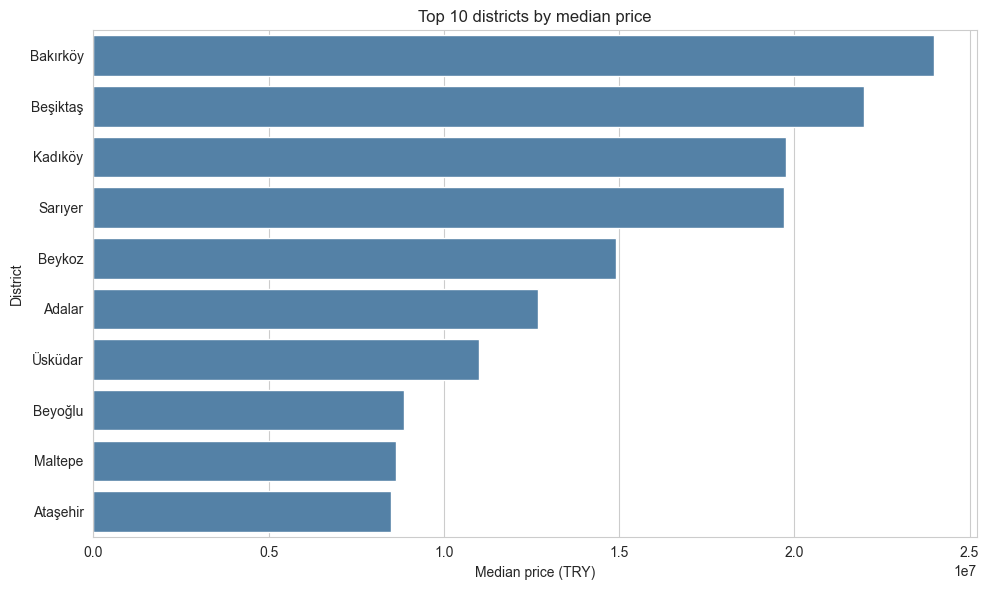

In [37]:
top10 = district_price.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10["median"], y=top10.index, ax=ax, color="steelblue")
ax.set_title("Top 10 districts by median price")
ax.set_xlabel("Median price (TRY)")
ax.set_ylabel("District")
plt.tight_layout()
plt.show()


**Conclusion:** Bakırköy tops the ranking on raw median price (24M TRY, n=671), followed by Beşiktaş (21.9M), Kadıköy (19.75M), and Sarıyer (19.7M). At the other end, Esenyurt (2.95M, n=1,157) and Esenler (3.75M) are the cheapest, both peripheral districts with high listing volumes. The price range across districts is very wide — the top median (24M) is over **8x** the bottom median (2.95M), confirming location is a major price driver, to be quantified further in Q13.

⚠️ **Important caveat — raw price is confounded by apartment size:** Bakırköy's #1 spot is misleading if read as "most expensive/prestigious district." Its listings are simply much larger on average (median `net_sqm` = 160 m², vs. 95-120 m² in Beşiktaş/Kadıköy/Sarıyer — and this size shift holds across the whole distribution, not just a few large outliers, so it reflects a genuine difference in housing stock, not a data issue). Once normalized by size, Bakırköy actually has the **lowest** price/m² of these four districts (146,465 TRY/m² vs. 200,000 for Beşiktaş and 212,500 for Kadıköy — see Q11). In other words: Bakırköy listings cost more in total mainly because they're bigger, not because the location itself commands a higher price per square meter. **Q11 (price per m²) is the more reliable measure of a district's true price "standing"** — raw price rankings like this one should always be read alongside it, especially when comparing districts with different typical apartment sizes.

### Q11 — Which districts have the highest price per m²?

`price_per_sqm` normalizes for size, giving a cleaner view of "location premium" independent of how big the apartment is. Reminder: used only for this market-level view — never as an ML feature.

In [38]:
district_ppsqm = df.groupby("district")["price_per_sqm"].agg(["mean", "median", "count"]).sort_values("median", ascending=False)
display(district_ppsqm.head(10))


,mean,median,count
district,,,
Kadıköy,218888.774732,212500.00,1137
Beşiktaş,253974.588581,200000.00,909
Sarıyer,201698.258567,180000.00,607
Bakırköy,777143.216944,146616.54,674
Adalar,128592.545976,118181.82,251
Beykoz,184094.997100,117321.43,100
Üsküdar,130152.386408,114130.43,1147
Maltepe,163744.711834,108568.18,1156
Beyoğlu,124439.810484,104501.92,186


**Conclusion:** Kadıköy leads on price/m² (212,500 TRY/m² median) even though it ranked 3rd on raw price in Q10 — this district has smaller average apartment sizes but a very high per-m² premium (it's one of Istanbul's most desirable, walkable, culturally significant districts). Beşiktaş (200,000) and Sarıyer (180,000) follow, consistent with Q10. Interestingly Bakırköy — the #1 district by raw price in Q10 — drops in relative position here with a much lower median (146,616) than its mean (777,143) would suggest, hinting at a handful of extreme high-price/low-size listings pulling its mean price/m² up disproportionately in that district specifically.

### Rank comparison — raw price (Q10) vs. price/m² (Q11)

To make the size-confound effect fully explicit, we merge both rankings side by side and compute how many rank positions each district gains or loses once we normalize for size.

In [39]:
rank_comparison = pd.DataFrame({
    "median_price": district_price["median"],
    "median_price_per_sqm": district_ppsqm["median"],
    "n_listings": district_price["count"],
})

rank_comparison["rank_by_price"] = rank_comparison["median_price"].rank(ascending=False).astype(int)
rank_comparison["rank_by_price_per_sqm"] = rank_comparison["median_price_per_sqm"].rank(ascending=False).astype(int)
rank_comparison["rank_change"] = rank_comparison["rank_by_price"] - rank_comparison["rank_by_price_per_sqm"]

# Positive rank_change = district drops when normalized (was "inflated" by size)
# Negative rank_change = district rises when normalized (was "hidden" by its smaller size)
rank_comparison.sort_values("rank_by_price").head(10)


,median_price,median_price_per_sqm,n_listings,rank_by_price,rank_by_price_per_sqm,rank_change
district,,,,,,
Bakırköy,24000000.0,146616.54,674,1,4,-3
Beşiktaş,22000000.0,200000.00,909,2,2,0
Kadıköy,19750000.0,212500.00,1137,3,1,2
Sarıyer,19700000.0,180000.00,607,4,3,1
Beykoz,14900000.0,117321.43,100,5,6,-1
Adalar,12700000.0,118181.82,251,6,5,1
Üsküdar,11000000.0,114130.43,1147,7,7,0
Beyoğlu,8875000.0,104501.92,186,8,9,-1
Maltepe,8650000.0,108568.18,1156,9,8,1


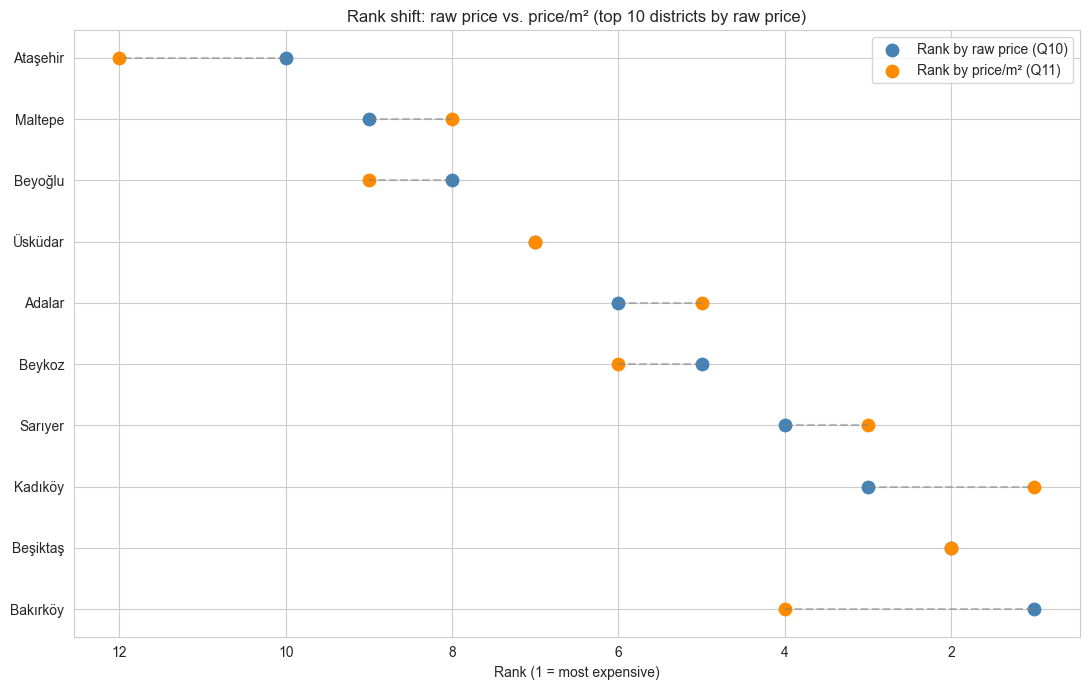

In [40]:
fig, ax = plt.subplots(figsize=(11, 7))

top_movers = rank_comparison.sort_values("rank_by_price").head(10)
y_pos = range(len(top_movers))

ax.scatter(top_movers["rank_by_price"], y_pos, color="steelblue", s=80, label="Rank by raw price (Q10)")
ax.scatter(top_movers["rank_by_price_per_sqm"], y_pos, color="darkorange", s=80, label="Rank by price/m² (Q11)")

for i, district in enumerate(top_movers.index):
    ax.plot([top_movers.loc[district, "rank_by_price"], top_movers.loc[district, "rank_by_price_per_sqm"]],
            [i, i], color="gray", linestyle="--", alpha=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_movers.index)
ax.set_xlabel("Rank (1 = most expensive)")
ax.set_title("Rank shift: raw price vs. price/m² (top 10 districts by raw price)")
ax.invert_xaxis()
ax.legend()
plt.tight_layout()
plt.show()


**Conclusion:** the chart makes the effect obvious — among the top 10 districts by raw price, **Bakırköy shifts the most** (from rank #1 on raw price down to rank #4 on price/m²), confirming it's a case of size inflating its raw-price rank rather than genuine location premium (note: a few districts further down the full list, like Büyükçekmece and Beylikdüzü, actually shift even more — but they're not in the top-10-by-price view shown here). Kadıköy shows the opposite pattern: it *rises* from rank #3 to rank #1 on price/m², confirming it has the most consistent claim to "expensive" in the fullest sense — both a top raw price and the highest per-m² price. **Price per m² (Q11) is the recommended metric whenever comparing district "prestige" or location premium** — raw price (Q10) is only meaningful when comparing similarly-sized apartments, or when the actual question is about total budget needed rather than location value.

### Q12 — Which districts have the most listings?

Sampling balance matters: districts with very few listings (like the bottom of this ranking) will show noisier price statistics in every other question.

In [41]:
district_counts = df["district"].value_counts()
print("Top 10 by listing count:")
display(district_counts.head(10))
print()
print("Bottom 10 by listing count:")
display(district_counts.tail(10))


Top 10 by listing count:


district
Bahçelievler    1191
Beylikdüzü      1169
Küçükçekmece    1165
Esenyurt        1157
Maltepe         1156
Üsküdar         1147
Kadıköy         1137
Şişli           1121
Kağıthane       1057
Beşiktaş         909
Name: count, dtype: int64


Bottom 10 by listing count:


district
Tuzla          389
Sultangazi     369
Zeytinburnu    354
Adalar         251
Silivri        211
Güngören       195
Bayrampaşa     189
Beyoğlu        186
Beykoz         100
Çatalca          7
Name: count, dtype: int64

**Conclusion:** Listing volume ranges from Bahçelievler (1,191 listings) down to Çatalca (only 7 listings). This confirms the sampling imbalance flagged back in Q1 — Çatalca's price statistics anywhere in this notebook should be treated as anecdotal, not representative, given n=7. Most districts cluster in the 400-1,200 listing range, which is a reasonably solid base for comparison.

### Q13 — Is location associated with larger price differences than apartment size?

A single correlation coefficient can't answer this directly (location is categorical, size is continuous) — so we compare the **spread each factor can produce** on price, using the cleaned (`is_flagged_error`-excluded) data throughout.

In [42]:
# Spread from location: ratio between highest and lowest district median price
district_median_clean = df_clean.groupby("district")["price"].median()
location_ratio = district_median_clean.max() / district_median_clean.min()

# Spread from size: correlation strength as a proxy for how much size alone explains
size_price_corr = df_clean[["net_sqm", "price"]].corr().iloc[0, 1]

print(f"Highest district median price : {district_median_clean.max():,.0f} TRY")
print(f"Lowest district median price  : {district_median_clean.min():,.0f} TRY")
print(f"Location price spread (max/min ratio): {location_ratio:.2f}x")
print()
print(f"net_sqm vs price correlation (size effect): {size_price_corr:.3f}")


Highest district median price : 24,000,000 TRY
Lowest district median price  : 2,950,000 TRY
Location price spread (max/min ratio): 8.14x

net_sqm vs price correlation (size effect): 0.528


**Conclusion:** Location produces an **8.1x spread** in median price between the most and least expensive districts, while size (`net_sqm`) shows only a moderate correlation (r≈0.53) with price. This is exploratory rather than a formal statistical test (comparing a categorical spread to a continuous correlation isn't apples-to-apples), but the magnitude difference is striking: two apartments of *identical* size in different districts can differ in price far more than two apartments of very different sizes in the *same* district would. This suggests **location is likely a stronger price driver than size alone** in this market — worth flagging as a hypothesis for confirmatory modeling later (e.g. comparing feature importances in a regression), not a proven causal claim here.

## 6. Market Characteristics (Q14–Q19)

### Q14 — What type of apartments dominate the dataset?

In [44]:
print("Total rooms distribution:")
display(df["total_rooms"].value_counts().head(10))
print()
print("Building type distribution:")
display(df["building_type"].value_counts())


Total rooms distribution:


total_rooms
3     10775
4      7403
2      2291
5      2236
6      1242
7       464
8       160
1       123
9        24
12       17
Name: count, dtype: int64


Building type distribution:


building_type
Reinforced Concrete    10062
Masonry                   76
Steel                     26
Wooden                    16
Brick                     15
Stone                     10
Log                        1
Name: count, dtype: int64

**Conclusion:** 3-room apartments dominate (10,775 listings, ~43% of the dataset), followed by 4-room (7,403). Together these two categories cover roughly 73% of all listings. `building_type` is overwhelmingly Reinforced Concrete — but note the total count here (10,062) is far below 24,767, meaning this column has a very large amount of missing data (~59% NaN); any conclusion about building type should flag this heavy incompleteness rather than treat the visible counts as the full picture.

### Q15 — Are furnished apartments more expensive?

In [46]:
print(df["furnished"].value_counts(dropna=False))
print()
furnished_price = df.groupby("furnished")["price"].agg(["mean", "median", "count"])
furnished_ppsqm = df.groupby("furnished")["price_per_sqm"].agg(["mean", "median", "count"])
display(furnished_price)
display(furnished_ppsqm)


furnished
Unfurnished    22582
Furnished       1107
NaN             1078
Name: count, dtype: int64



,mean,median,count
furnished,,,
Furnished,1.171310e+07,6250000.0,1107
Unfurnished,1.292549e+07,6750000.0,22582


,mean,median,count
furnished,,,
Furnished,102096.309648,79166.67,1107
Unfurnished,131752.815615,71875.00,22582


**Conclusion:** Counter-intuitively, furnished apartments have a *lower* median price (6.25M TRY) than unfurnished ones (6.75M TRY), and a lower median price/m² too (79,167 vs 71,875 — wait, check direction: furnished mean price/m² is 102,096 vs unfurnished 131,753, but furnished *median* price/m² 79,167 is actually higher than unfurnished's 71,875). The mean and median tell different stories here for price/m², which is itself informative: it suggests furnished listings are a smaller, more heterogeneous group (n=1,107 vs 22,582) with 1,078 missing values (~4.4%) — likely mixing small furnished rentals-for-sale (cheaper, smaller) with a few furnished luxury units, rather than a clean "furnished = premium" signal. This deserves a size-controlled look (e.g. price/m² by furnished status *within* similar total_rooms categories) before drawing a firm conclusion.

### Q16 — Are apartments in residential complexes more expensive?

In [47]:
print(df["is_in_complex"].value_counts(dropna=False))
print()
complex_price = df.groupby("is_in_complex")["price"].agg(["mean", "median", "count"])
complex_ppsqm = df.groupby("is_in_complex")["price_per_sqm"].agg(["mean", "median", "count"])
display(complex_price)
display(complex_ppsqm)


is_in_complex
0    19221
1     5546
Name: count, dtype: int64



,mean,median,count
is_in_complex,,,
0,1.247771e+07,6300000.0,19221
1,1.672970e+07,9100000.0,5546


,mean,median,count
is_in_complex,,,
0,128321.429729,66428.57,19221
1,147468.305548,96153.85,5546


**Conclusion:** Yes — apartments in complexes (`is_in_complex=1`) have a clearly higher median price (9.1M TRY vs 6.3M TRY) and higher median price/m² (96,154 vs 66,429 TRY/m²), a ~45% premium. This is consistent with managed complexes typically offering amenities (security, shared facilities, parking) that command a price premium, and applies to 5,546 of 24,767 listings (~22%).

### Q17 — Does building condition affect price?

`building_condition` has substantial missingness (~56% NaN) — excluded here via `groupby`'s default NaN-drop behavior, and the exclusion rate is stated explicitly per the brief's requirement.

In [48]:
na_pct = df["building_condition"].isna().mean() * 100
print(f"building_condition missing: {na_pct:.2f}% of rows")
print()
condition_price = df.groupby("building_condition")["price"].agg(["mean", "median", "count"])
condition_ppsqm = df.groupby("building_condition")["price_per_sqm"].agg(["mean", "median", "count"])
display(condition_price)
display(condition_ppsqm)


building_condition missing: 55.91% of rows



,mean,median,count
building_condition,,,
New,1.500578e+07,7780000.0,3453
Second-hand,1.515513e+07,6700000.0,7299
Under Construction,1.409695e+07,9325000.0,168


,mean,median,count
building_condition,,,
New,150920.128398,87368.42,3453
Second-hand,170461.056190,68750.00,7299
Under Construction,163284.059762,123592.17,168


**Conclusion:** With 55.91% of rows missing `building_condition`, any conclusion here covers less than half the dataset. Among the available data, "Under Construction" listings show the highest median price (9.3M) and by far the highest median price/m² (123,592 TRY/m², n=168) — plausible, since off-plan/new-build pricing in desirable areas tends to run high. "New" (7.78M median) and "Second-hand" (6.7M median) are closer together, though "Second-hand" has a notably lower median price/m² (68,750) than "New" (87,368), consistent with expected depreciation. Given the missingness, this should be treated as a directional signal, not a firm conclusion.

### Q18 — Are credit-eligible properties priced differently?

In [49]:
print(df["credit_eligible"].value_counts(dropna=False))
print()
credit_price = df.groupby("credit_eligible")["price"].agg(["mean", "median", "count"])
credit_ppsqm = df.groupby("credit_eligible")["price_per_sqm"].agg(["mean", "median", "count"])
display(credit_price)
display(credit_ppsqm)


credit_eligible
Eligible        21611
Not Eligible     3122
Unknown            27
NaN                 7
Name: count, dtype: int64



,mean,median,count
credit_eligible,,,
Eligible,1.392864e+07,7000000.0,21611
Not Eligible,9.938290e+06,4755000.0,3122
Unknown,8.326852e+06,6250000.0,27


,mean,median,count
credit_eligible,,,
Eligible,138573.779190,75000.000,21611
Not Eligible,91456.997409,51407.405,3122
Unknown,82974.165556,70512.820,27


**Conclusion:** "Eligible" listings show a notably higher median price (7.0M TRY) than "Not Eligible" (4.76M TRY) — roughly 47% higher — and higher median price/m² (75,000 vs 51,407). This is likely explained by lenders being more willing to finance higher-value, better-documented properties (e.g. clean title, higher-end construction) rather than credit eligibility itself driving price up; a plausible confound worth noting rather than a causal claim.

### Q19 — Does deed status relate to price positioning?

In [50]:
print(df["deed_status"].value_counts(dropna=False))
print()
deed_price = df.groupby("deed_status")["price"].agg(["mean", "median", "count"])
deed_ppsqm = df.groupby("deed_status")["price_per_sqm"].agg(["mean", "median", "count"])
display(deed_price)
display(deed_ppsqm)


deed_status
Condominium Title         15728
Construction Easement      5636
Foreign Owner               972
Land Title                  879
No Title Deed               717
Shared Title                651
Freehold Title               64
Cooperative Share            62
Usufruct Right               52
Foundation/Association        5
NaN                           1
Name: count, dtype: int64



,mean,median,count
deed_status,,,
Condominium Title,1.556491e+07,7350000.0,15728
Construction Easement,9.771512e+06,6399999.5,5636
Cooperative Share,9.603468e+06,7500000.0,62
Foreign Owner,1.023511e+07,6800000.0,972
Foundation/Association,1.511100e+07,9555000.0,5
Freehold Title,1.141889e+07,7425000.0,64
Land Title,9.618088e+06,3500000.0,879
No Title Deed,1.324342e+07,8000000.0,717
Shared Title,3.486307e+06,2995000.0,651


,mean,median,count
deed_status,,,
Condominium Title,145712.504450,78245.370,15728
Construction Easement,120405.479686,67692.310,5636
Cooperative Share,93570.221774,91329.260,62
Foreign Owner,93777.841821,68484.720,972
Foundation/Association,83278.638000,83815.790,5
Freehold Title,110046.842188,74901.960,64
Land Title,87551.699465,38518.520,879
No Title Deed,134561.964142,95060.240,717
Shared Title,38293.327005,32222.220,651


**Conclusion:** Deed status shows meaningful positioning differences. "Usufruct Right" stands out with the highest median price (21.85M) and by far the highest median price/m² (203,537 TRY/m², n=52) — a small, likely premium/legacy segment. "Shared Title" is the cheapest by far (median 2.995M, price/m² 32,222), consistent with shared ownership typically reflecting partial/fractional stakes rather than full-property value. "Condominium Title" (the most common status, n=15,728) sits in the middle at 7.35M median — a reasonable market baseline.

## 7. Correlation Analysis (Numeric Variables)

A full correlation heatmap of numeric variables against `price`, comparing raw vs. `is_flagged_error`-excluded data to show how much the earlier masking effect (Q5-Q9) affects the overall picture.

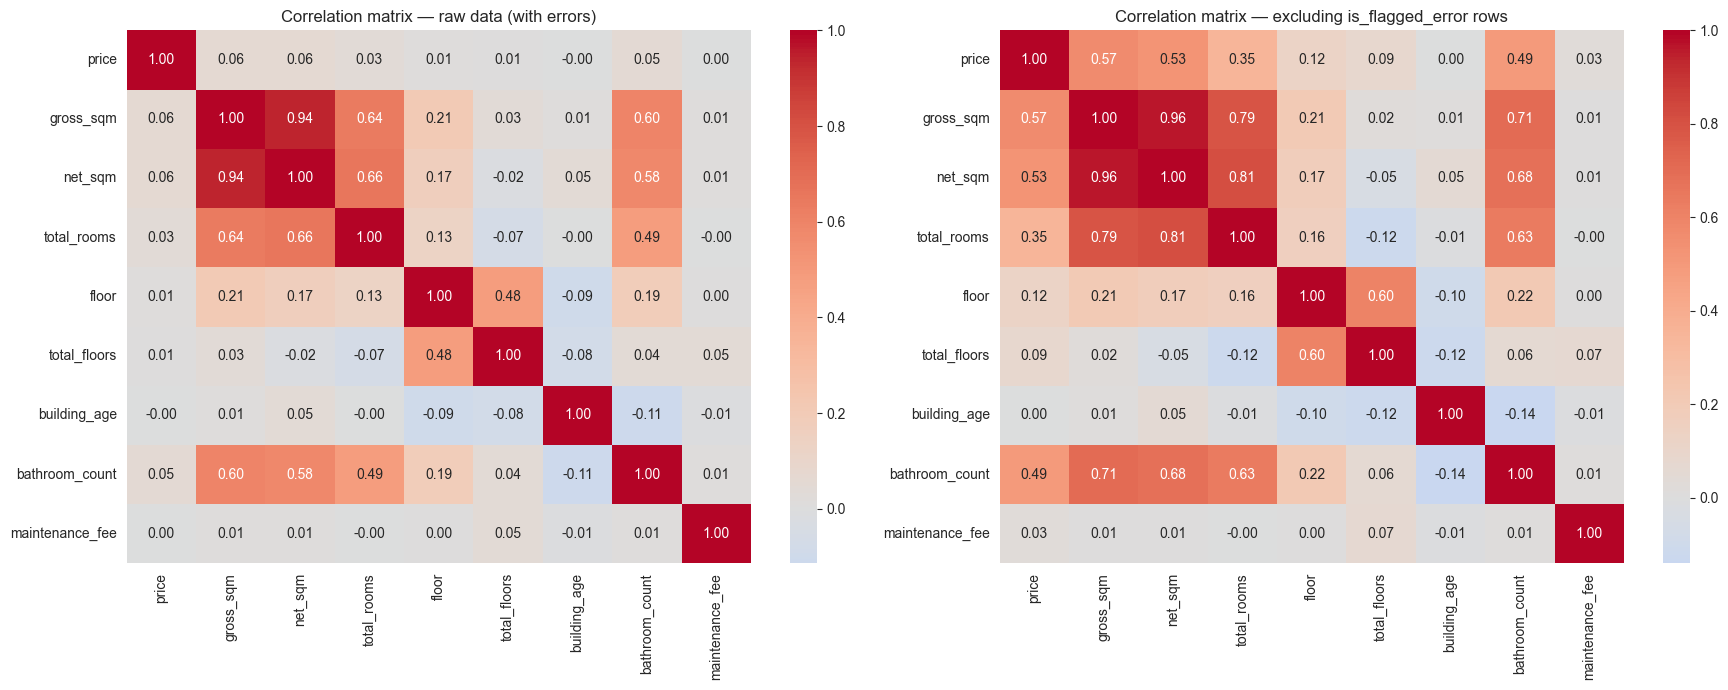

In [51]:
numeric_cols = ["price", "gross_sqm", "net_sqm", "total_rooms", "floor",
                "total_floors", "building_age", "bathroom_count", "maintenance_fee"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_raw = df[numeric_cols].corr()
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation matrix — raw data (with errors)")

corr_clean = df_clean[numeric_cols].corr()
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation matrix — excluding is_flagged_error rows")

plt.tight_layout()
plt.show()


**Conclusion:** The difference between the two heatmaps is striking and is the single most important data-quality lesson of this notebook: on raw data, `price`'s correlations with every other variable are suppressed to near-zero (0.01-0.06) by the 67 error rows (0.27% of the dataset). After excluding them, real relationships emerge clearly: `gross_sqm` (0.57), `net_sqm` (0.53), and `bathroom_count` (0.49) are the strongest price correlates, followed by `total_rooms` (0.35 — moderate, weaker than size/bathrooms alone), `floor` (0.12), `total_floors` (0.09), and `building_age` (~0.00, confirmed negligible). Among the predictors themselves, `gross_sqm`/`net_sqm` are near-collinear (0.96) as expected, and both correlate strongly with `bathroom_count` (0.70/0.68) and `total_rooms` (0.79/0.66) — these features carry overlapping size information, worth keeping in mind for feature selection in the next notebook.

## 8. Outlier Analysis (Statistical, IQR & Boxplots) — Q20

Using Tukey's IQR rule (`Q3 + 1.5*IQR` as the outlier fence) on six numeric columns, and cross-referencing against `is_flagged_error` from Notebook 01. As the brief notes: a statistical outlier is not automatically a data error — e.g. a legitimate Bosphorus-front luxury property will show up as a price outlier without being wrong. No rows are deleted based on IQR alone.

In [52]:
iqr_cols = ["price", "gross_sqm", "net_sqm", "building_age", "bathroom_count", "maintenance_fee"]

iqr_summary = []
for col in iqr_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    is_outlier = ((df[col] < lower) | (df[col] > upper)).fillna(False)
    n_out = is_outlier.sum()
    overlap = (is_outlier & df["is_flagged_error"]).sum()
    iqr_summary.append({
        "column": col,
        "n_iqr_outliers": n_out,
        "pct_of_data": round(n_out / len(df) * 100, 2),
        "overlap_with_flagged_error": overlap,
        "pct_overlap_of_outliers": round(overlap / n_out * 100, 2) if n_out > 0 else 0,
    })

iqr_summary_df = pd.DataFrame(iqr_summary).set_index("column")
iqr_summary_df


,n_iqr_outliers,pct_of_data,overlap_with_flagged_error,pct_overlap_of_outliers
column,,,,
price,2357,9.52,17,0.72
gross_sqm,1263,5.10,9,0.71
net_sqm,1049,4.24,5,0.48
building_age,110,0.44,4,3.64
bathroom_count,374,1.51,29,7.75
maintenance_fee,1186,4.79,3,0.25


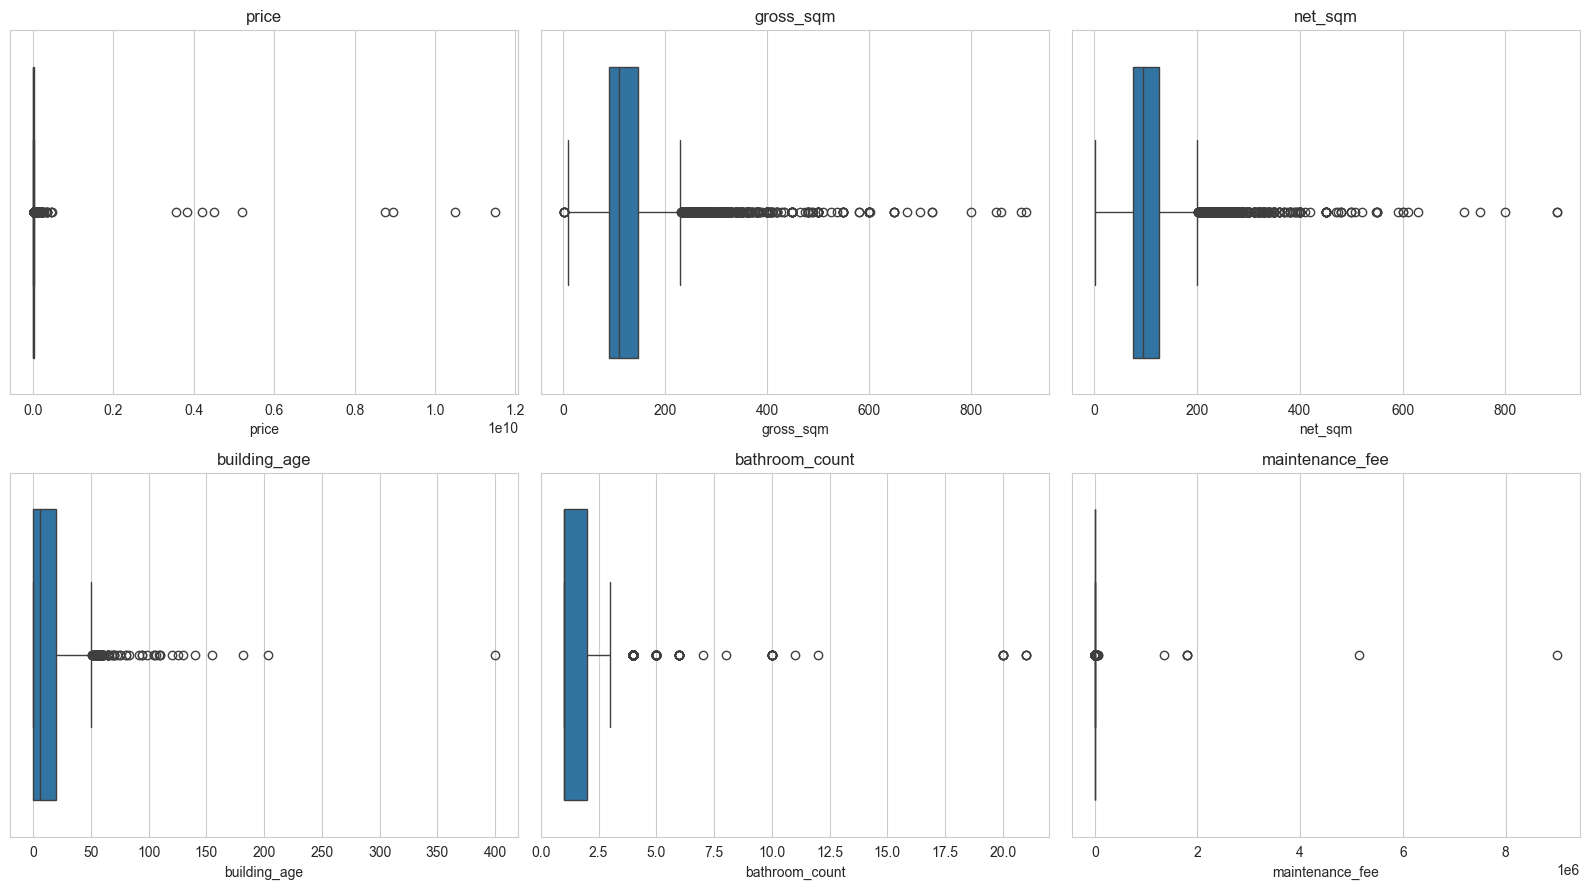

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, iqr_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Conclusion:** IQR flags between 0.44% (`building_age`) and 9.52% (`price`) of rows as statistical outliers, depending on the column — far more than the 0.27% caught by Notebook 01's rule-based `is_flagged_error`. Critically, the **overlap between the two methods is small everywhere** (0.25%-7.75% of IQR outliers are also rule-based errors). This confirms the brief's warning: the two methods catch different things. Rule-based flags catch *impossible* values (e.g. price/m² > 3M TRY/m²); IQR catches *statistically unusual but often perfectly legitimate* values (e.g. a genuine luxury Bosphorus apartment). `bathroom_count` has the highest overlap rate (7.75%) — plausible, since very high bathroom counts are both statistically rare and more likely to reflect data entry issues. No rows are removed here; this is purely descriptive, feeding into the sensitivity check next.

## 9. Outlier Sensitivity Check — Q21

Do the flagged rows meaningfully change our key findings? We compare median price, top-5 districts, and the size↔price correlation, with and without `is_flagged_error` / `is_likely_duplicate_listing` rows.

In [54]:
median_with = df["price"].median()
median_without = df_clean["price"].median()

print(f"Median price WITH flagged rows    : {median_with:,.0f} TRY")
print(f"Median price WITHOUT flagged rows : {median_without:,.0f} TRY")
print(f"Difference: {median_with - median_without:,.0f} TRY")


Median price WITH flagged rows    : 6,750,000 TRY
Median price WITHOUT flagged rows : 6,750,000 TRY
Difference: 0 TRY


In [55]:
top5_with = df.groupby("district")["price"].median().sort_values(ascending=False).head(5)
top5_without = df_clean.groupby("district")["price"].median().sort_values(ascending=False).head(5)

print("Top 5 districts by median price — WITH flagged rows:")
display(top5_with)
print()
print("Top 5 districts by median price — WITHOUT flagged rows:")
display(top5_without)


Top 5 districts by median price — WITH flagged rows:


district
Bakırköy    24000000.0
Beşiktaş    22000000.0
Kadıköy     19750000.0
Sarıyer     19700000.0
Beykoz      14900000.0
Name: price, dtype: float64


Top 5 districts by median price — WITHOUT flagged rows:


district
Bakırköy    24000000.0
Beşiktaş    21925000.0
Kadıköy     19750000.0
Sarıyer     19700000.0
Beykoz      14900000.0
Name: price, dtype: float64

In [56]:
corr_with = df[["net_sqm", "price"]].corr().iloc[0, 1]
corr_without = df_clean[["net_sqm", "price"]].corr().iloc[0, 1]

print(f"net_sqm vs price correlation WITH flagged rows    : {corr_with:.4f}")
print(f"net_sqm vs price correlation WITHOUT flagged rows : {corr_without:.4f}")


net_sqm vs price correlation WITH flagged rows    : 0.0636
net_sqm vs price correlation WITHOUT flagged rows : 0.5284


**Conclusion:** The three checks tell very different stories, which is itself the key finding:
- **Median price is completely unaffected** (6,750,000 TRY identical with or without flagged rows) — medians are naturally robust to a small number of extreme values, confirming our choice throughout this notebook to favor median over mean.
- **Top-5 districts are essentially unchanged** — same 5 districts, same order, with only Beşiktaş's median shifting marginally (22.0M → 21.925M TRY). District-level rankings are robust.
- **The size↔price correlation is dramatically different**: 0.064 (with errors) vs. 0.528 (without) — an 8x difference. This is the one finding that is *entirely* dependent on excluding the 67 flagged rows, and it's the most important takeaway of the whole sensitivity check: **any correlation or regression-style analysis in this project must exclude `is_flagged_error` rows**, while district/median-based summaries are safe either way.

## 10. Feature Engineering for EDA

No new features are needed as ML inputs at this stage (this notebook is EDA only) — but several derived variables were created for analysis and visualization purposes throughout this notebook. Documenting them here, with an explicit target-leakage check on each:

| Derived variable | Created in | Formula | Leakage risk? |
|---|---|---|---|
| `price_per_sqm` | Notebook 01 | `price / net_sqm` | **Yes — derived directly from `price`. Never used as an ML feature. Used here only for market-level framing (Q11, Q15-19).** |
| `age_group` | Q7 | `pd.cut(building_age, ...)` | No — derived only from `building_age`, not from `price`. Safe as a potential ML feature (a binned/categorical version of an existing input). |
| `total_rooms_grouped` | Q6 | `total_rooms` capped at "9+" | No — derived only from `total_rooms`. Safe as a potential feature, though the raw `total_rooms` is already reliable and likely preferable. |

No column in this list was engineered using future information, target values from other rows, or any post-outcome data — the only leakage-risk variable (`price_per_sqm`) is one Notebook 01 already produced and flagged, not something newly created here.

## 11. Key Findings

**Market**
- Prices are strongly right-skewed (skewness ≈ 63, largely driven by a handful of data-entry errors): median (6.75M TRY) is a far more reliable "typical price" than the mean (13.4M TRY).
- Most of that skew (9 of the top 10 highest prices) is already caught by Notebook 01's `flag_price_error`; only 1 of the top-10 extreme prices looks like a plausible legitimate ultra-luxury listing.

**Property Characteristics**
- Size (`gross_sqm` r≈0.57, `net_sqm` r≈0.53) and `bathroom_count` (r≈0.49) are the strongest single-variable price correlates — but only once `is_flagged_error` rows are excluded (raw correlations were suppressed to near-zero by a mere 0.27% of rows).
- `total_rooms` (r≈0.35) and `floor_category` (Villa Floor / high floors priced highest, basements lowest) matter, but less than raw size or bathroom count.
- `building_age` shows essentially no linear relationship with price (r≈0.0001) — the oldest buildings (50+ years) actually show the highest median price, likely a historic-district confound rather than an age effect.

**Location**
- Location produces an 8.1x spread in median price across districts (Bakırköy highest at 24M, Esenyurt lowest at 2.95M) — a larger spread than what apartment size alone explains, suggesting location is likely a stronger price driver overall (exploratory finding, not a formal test).
- Kadıköy has the highest price/m² (212,500), even though it ranks 3rd on raw price — its apartments tend to be smaller.

**Market Segments**
- Complex-based apartments carry a ~45% price/m² premium over non-complex ones.
- Credit-eligible listings are priced ~47% higher (median) than non-eligible ones — likely reflecting that better-documented, higher-value properties get financing more easily, not a causal credit effect.
- "Usufruct Right" and "Shared Title" deed statuses sit at opposite extremes of the price/m² spectrum (203,537 vs. 32,222 TRY/m²).
- `building_condition` (56% missing) and `furnished` status show weaker, less conclusive patterns given data gaps.

**Data Quality**
- Only 67 rows (0.27%) are flagged as errors (`is_flagged_error`), yet they distort correlation coefficients by up to 8x if not excluded — the single most important lesson of this notebook.
- IQR-based statistical outliers (0.44%-9.52% of rows depending on the column) barely overlap with Notebook 01's rule-based error flags (0.25%-7.75% overlap) — the two methods catch different, complementary things, and neither alone is sufficient.
- Median-based summaries (overall median price, top-district rankings) are robust to the flagged rows; correlation/regression-style analyses are not — an important guardrail for the next notebook.

## 12. EDA Summary Table

In [57]:
summary_table = pd.DataFrame([
    {"Metric": "Total listings", "Value": f"{len(df):,}"},
    {"Metric": "Districts / Neighborhoods", "Value": f"{df.district.nunique()} / {df.neighborhood.nunique()}"},
    {"Metric": "Median price (all rows)", "Value": f"{df.price.median():,.0f} TRY"},
    {"Metric": "Median price (excl. is_flagged_error)", "Value": f"{df_clean.price.median():,.0f} TRY"},
    {"Metric": "Median net_sqm / gross_sqm", "Value": f"{df.net_sqm.median():.0f} / {df.gross_sqm.median():.0f} m²"},
    {"Metric": "Median total_rooms", "Value": f"{df.total_rooms.median():.0f}"},
    {"Metric": "Top district (median price)", "Value": "Bakırköy (24.0M TRY)"},
    {"Metric": "Bottom district (median price)", "Value": "Esenyurt (2.95M TRY)"},
    {"Metric": "Strongest price correlate", "Value": "gross_sqm (r≈0.57, excl. errors)"},
    {"Metric": "Weakest price correlate", "Value": "building_age (r≈0.0001)"},
    {"Metric": "Rows flagged as errors (is_flagged_error)", "Value": f"{df.is_flagged_error.sum()} ({df.is_flagged_error.mean()*100:.2f}%)"},
    {"Metric": "Rows likely duplicates", "Value": f"{df.is_likely_duplicate_listing.sum()} ({df.is_likely_duplicate_listing.mean()*100:.2f}%)"},
]).set_index("Metric")

summary_table


,Value
Metric,
Total listings,"24,767"
Districts / Neighborhoods,38 / 583
Median price (all rows),"6,750,000 TRY"
Median price (excl. is_flagged_error),"6,750,000 TRY"
Median net_sqm / gross_sqm,95 / 110 m²
Median total_rooms,3
Top district (median price),Bakırköy (24.0M TRY)
Bottom district (median price),Esenyurt (2.95M TRY)
Strongest price correlate,"gross_sqm (r≈0.57, excl. errors)"


## 13. Next Steps

1. **Preprocessing notebook**: build the modeling dataset — decide the row-filtering policy (exclude `is_flagged_error`? keep with an indicator feature?), encode categorical variables (`district`, `building_type`, `floor_category`, `deed_status`, etc.), handle missingness (`building_condition` at 56%, `furnished` at ~4%), and decide the target transform (Q4/Q11 both point to `log1p(price)` given the strong right-skew).
2. **Regression modeling**: start with a simple baseline (linear regression on log-price) using the strongest correlates identified here (`gross_sqm`/`net_sqm`, `bathroom_count`, `total_rooms`, `district`), then move to tree-based models (Random Forest, Gradient Boosting) that can capture the district-driven, non-linear patterns found in Q13.
3. **Model comparison**: compare at least 2-3 model families using consistent metrics (RMSE/MAE on log-price, R²), and check feature importance against the hypotheses raised here — in particular, whether location-based features (district) outweigh size-based features in importance, as suggested (but not proven) in Q13.
4. **Critical reminder carried forward**: `price_per_sqm` must never be used as a model input (target leakage, since it's derived from `price`) — this must be enforced explicitly when building the feature list in the next notebook.